In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
#correlation matrix containing only numerical columns.
df.corr(numeric_only = True)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293123,0.016660,0.008148,-0.006130,-0.001791,0.024765,0.060017,0.005048,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,-0.083114,-0.020642,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,-0.124410,0.086042,-0.073548,0.000149,-0.069741,0.151464,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,0.016660,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,0.010341,-0.119822,0.029218,0.030872,0.063457,0.259095,-0.056497,0.197580,-0.013684,0.108531
arrival_date_week_number,0.008148,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,-0.030131,0.035501,-0.020904,0.005508,-0.031201,-0.076760,0.022933,0.075791,0.001920,0.026149
arrival_date_day_of_month,-0.006130,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,-0.006145,-0.027011,-0.000300,0.010613,0.001487,0.044858,0.022728,0.030245,0.008683,0.003062
stays_in_weekend_nights,-0.001791,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,-0.087239,-0.012775,-0.042715,0.063281,0.140739,0.066749,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,0.182382,0.182211,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.035594,0.207793,-0.008283,0.230641,0.014785,0.122884
children,0.005048,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,-0.032859,-0.024730,-0.021072,0.048949,0.041066,0.030931,-0.033273,0.324854,0.056253,0.081745
babies,-0.032491,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,0.036184,0.019206,-0.010621,0.029186,0.037383,0.097889


In [3]:
#covariance matrix containing only numerical columns.
df.cov(numeric_only = True)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,0.233210,15.126964,0.005692,0.053534,-0.025994,-0.000864,0.022822,0.016789,0.000972,-0.001529,-0.007197,0.044906,-0.041478,-0.045481,-4.490794,-1.033208,0.460407,1.160602,-0.023158,-0.089840
lead_time,15.126964,11419.721511,3.034866,184.455853,2.127750,9.142389,33.810687,7.398401,-1.602367,-0.217774,-2.336794,7.763414,-11.769232,0.010375,-831.818443,1662.193716,319.796767,-340.640932,-3.052469,-8.108810
arrival_date_year,0.005692,3.034866,0.500522,-5.203069,-0.001373,0.015188,0.041694,0.012145,0.015402,-0.000909,0.001286,-0.071575,0.030954,0.014247,4.964410,24.361820,-0.703261,7.064052,-0.002375,0.060874
arrival_date_week_number,0.053534,184.455853,-5.203069,185.099790,7.981327,0.247374,0.403932,0.204187,0.029924,0.013781,-0.072053,0.407810,-0.425865,0.048877,-45.917933,-157.348199,5.489676,52.109585,0.006409,0.282050
arrival_date_day_of_month,-0.025994,2.127750,-0.001373,7.981327,77.102966,-0.143405,-0.472085,-0.007965,0.050899,-0.000197,-0.009484,-0.200257,-0.003942,0.060788,1.448817,50.497157,3.511319,13.421189,0.018703,0.021317
stays_in_weekend_nights,-0.000864,9.142389,0.015188,0.247374,-0.143405,0.997229,0.950855,0.053144,0.018226,0.001798,-0.015313,-0.010771,-0.063875,0.041222,15.651660,7.052193,-0.951453,2.490075,-0.004545,0.057533
stays_in_week_nights,0.022822,33.810687,0.041694,0.403932,-0.472085,0.950855,3.641554,0.102775,0.033619,0.003754,-0.032617,-0.022545,-0.139284,0.119760,38.502691,40.709348,-0.067817,6.291289,-0.011636,0.103166
adults,0.016789,7.398401,0.012145,0.204187,-0.007965,0.053144,0.102775,0.335543,0.007029,0.001024,-0.014908,-0.003296,-0.093665,-0.019525,-1.936162,13.385137,-0.084423,6.751655,0.002101,0.056433
children,0.000972,-1.602367,0.015402,0.029924,0.050899,0.018226,0.033619,0.007029,0.158851,0.000933,-0.002302,-0.008322,-0.012577,0.012726,1.873407,0.642877,-0.233331,6.542931,0.005500,0.025830
babies,-0.001529,-0.217774,-0.000909,0.013781,-0.000197,0.001798,0.003754,0.001024,0.000933,0.009494,-0.000153,-0.000617,-0.000956,0.005303,0.388872,0.129959,-0.018207,0.143711,0.000893,0.007562


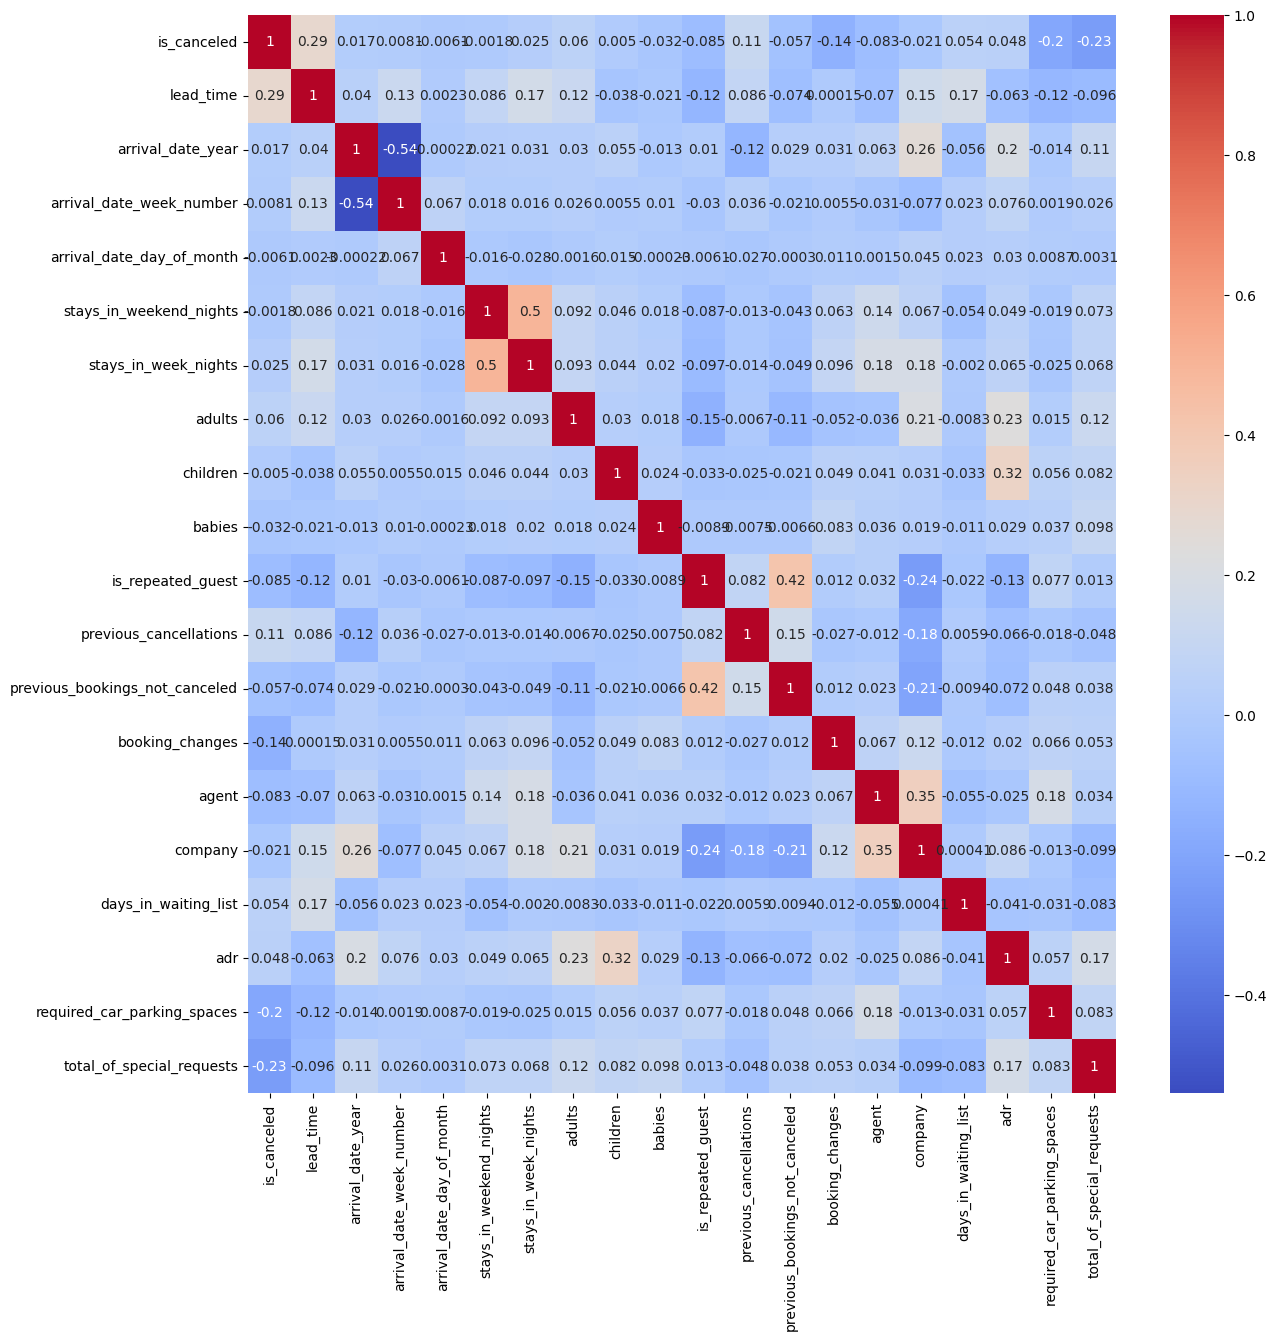

In [12]:
# correlation heatmap.
plt.figure(figsize = (14,14))
sns.heatmap(df.corr(numeric_only = True) , annot = True , cmap = "coolwarm")
plt.show()

In [19]:
# highest positive correlation with adr?
df.corr(numeric_only = True)["adr"].sort_values(ascending = False)

adr                               1.000000
children                          0.324854
adults                            0.230641
arrival_date_year                 0.197580
total_of_special_requests         0.172185
company                           0.086376
arrival_date_week_number          0.075791
stays_in_week_nights              0.065237
required_car_parking_spaces       0.056628
stays_in_weekend_nights           0.049342
is_canceled                       0.047557
arrival_date_day_of_month         0.030245
babies                            0.029186
booking_changes                   0.019618
agent                            -0.024695
days_in_waiting_list             -0.040756
lead_time                        -0.063077
previous_cancellations           -0.065646
previous_bookings_not_canceled   -0.072144
is_repeated_guest                -0.134314
Name: adr, dtype: float64

In [20]:
# strongest negative correlation with adr.
df.corr(numeric_only = True)["adr"].sort_values()

is_repeated_guest                -0.134314
previous_bookings_not_canceled   -0.072144
previous_cancellations           -0.065646
lead_time                        -0.063077
days_in_waiting_list             -0.040756
agent                            -0.024695
booking_changes                   0.019618
babies                            0.029186
arrival_date_day_of_month         0.030245
is_canceled                       0.047557
stays_in_weekend_nights           0.049342
required_car_parking_spaces       0.056628
stays_in_week_nights              0.065237
arrival_date_week_number          0.075791
company                           0.086376
total_of_special_requests         0.172185
arrival_date_year                 0.197580
adults                            0.230641
children                          0.324854
adr                               1.000000
Name: adr, dtype: float64

In [21]:
# Top 10 features most correlated with lead_time.
df.corr(numeric_only = True)["lead_time"].sort_values(ascending = False).head(10)

lead_time                   1.000000
is_canceled                 0.293123
days_in_waiting_list        0.170084
stays_in_week_nights        0.165799
company                     0.151464
arrival_date_week_number    0.126871
adults                      0.119519
previous_cancellations      0.086042
stays_in_weekend_nights     0.085671
arrival_date_year           0.040142
Name: lead_time, dtype: float64

In [23]:
# Top 10 features most correlated with total_of_special_requests.
df.corr(numeric_only = True)["total_of_special_requests"].sort_values(ascending = False).head(10)

total_of_special_requests      1.000000
adr                            0.172185
adults                         0.122884
arrival_date_year              0.108531
babies                         0.097889
required_car_parking_spaces    0.082626
children                       0.081745
stays_in_weekend_nights        0.072671
stays_in_week_nights           0.068192
booking_changes                0.052833
Name: total_of_special_requests, dtype: float64

In [41]:
# feature pairs having an absolute correlation greater than 0.80.
k = df.corr(numeric_only = True).abs()
mask = np.triu(np.ones(k.shape) , k = 1).astype(bool)
upper = k.where(mask)
pairs = upper.stack()
pairs[pairs > 0.80]

Series([], dtype: float64)

In [51]:
# feature pair having an absolute correlation less than 0.20.
k = df.corr(numeric_only = True).abs()
mask = np.triu(np.ones(k.shape) , k = 1).astype(bool)
upper = k.where(mask)
pairs = upper.stack()
pairs[pairs < 0.20]

is_canceled                  arrival_date_year              0.016660
                             arrival_date_week_number       0.008148
                             arrival_date_day_of_month      0.006130
                             stays_in_weekend_nights        0.001791
                             stays_in_week_nights           0.024765
                                                              ...   
days_in_waiting_list         required_car_parking_spaces    0.030600
                             total_of_special_requests      0.082730
adr                          required_car_parking_spaces    0.056628
                             total_of_special_requests      0.172185
required_car_parking_spaces  total_of_special_requests      0.082626
Length: 178, dtype: float64

In [56]:
# feature has the strongest overall relationship with all other numerical features?
df.corr(numeric_only = True).abs().sum().sort_values(ascending = False)


company                           3.368528
lead_time                         2.842607
adr                               2.785871
stays_in_week_nights              2.702609
is_repeated_guest                 2.663776
arrival_date_year                 2.636516
total_of_special_requests         2.533845
is_canceled                       2.480492
agent                             2.461350
stays_in_weekend_nights           2.406853
adults                            2.402885
previous_bookings_not_canceled    2.389610
arrival_date_week_number          2.144776
required_car_parking_spaces       2.057049
previous_cancellations            2.041771
children                          1.957560
booking_changes                   1.924579
days_in_waiting_list              1.693617
babies                            1.494976
arrival_date_day_of_month         1.291427
dtype: float64

In [58]:
# numerical feature appears almost unrelated to every other feature?
df.corr(numeric_only = True).abs().sum().sort_values(ascending = True)

arrival_date_day_of_month         1.291427
babies                            1.494976
days_in_waiting_list              1.693617
booking_changes                   1.924579
children                          1.957560
previous_cancellations            2.041771
required_car_parking_spaces       2.057049
arrival_date_week_number          2.144776
previous_bookings_not_canceled    2.389610
adults                            2.402885
stays_in_weekend_nights           2.406853
agent                             2.461350
is_canceled                       2.480492
total_of_special_requests         2.533845
arrival_date_year                 2.636516
is_repeated_guest                 2.663776
stays_in_week_nights              2.702609
adr                               2.785871
lead_time                         2.842607
company                           3.368528
dtype: float64

In [61]:
# Comparing the Pearson and Spearman correlations for lead_time.
print(df.corr(method = "pearson" , numeric_only = True)["lead_time"].sort_values(ascending = False))
print(df.corr(method = "spearman" , numeric_only = True)["lead_time"].sort_values(ascending = False))

lead_time                         1.000000
is_canceled                       0.293123
days_in_waiting_list              0.170084
stays_in_week_nights              0.165799
company                           0.151464
arrival_date_week_number          0.126871
adults                            0.119519
previous_cancellations            0.086042
stays_in_weekend_nights           0.085671
arrival_date_year                 0.040142
arrival_date_day_of_month         0.002268
booking_changes                   0.000149
babies                           -0.020915
children                         -0.037622
adr                              -0.063077
agent                            -0.069741
previous_bookings_not_canceled   -0.073548
total_of_special_requests        -0.095712
required_car_parking_spaces      -0.116451
is_repeated_guest                -0.124410
Name: lead_time, dtype: float64
lead_time                         1.000000
is_canceled                       0.316635
stays_in_week_nights  

In [66]:
# redundant features that could potentially be removed due to high correlation.
k = df.corr(numeric_only = True).abs()
mask = np.triu(np.ones(k.shape) , k = 1).astype(bool)
upper = k.where(mask)
pairs = upper.stack()
pairs[pairs > 0.90]

Series([], dtype: float64)

In [68]:
# all numerical features by their absolute correlation with adr.
df.corr(numeric_only = True).abs()["adr"].sort_values(ascending = False)

adr                               1.000000
children                          0.324854
adults                            0.230641
arrival_date_year                 0.197580
total_of_special_requests         0.172185
is_repeated_guest                 0.134314
company                           0.086376
arrival_date_week_number          0.075791
previous_bookings_not_canceled    0.072144
previous_cancellations            0.065646
stays_in_week_nights              0.065237
lead_time                         0.063077
required_car_parking_spaces       0.056628
stays_in_weekend_nights           0.049342
is_canceled                       0.047557
days_in_waiting_list              0.040756
arrival_date_day_of_month         0.030245
babies                            0.029186
agent                             0.024695
booking_changes                   0.019618
Name: adr, dtype: float64